<a href="https://colab.research.google.com/github/MafeMartinezOtero/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
nulos_por_columna = users.isnull().sum()
print('cantidad de nulos para users','\n','\n',nulos_por_columna)

cantidad de nulos para users 
 
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [ ]:
# cantidad de nulos para usage
porcentaje_users_nulos = users.isna().mean().sort_values(ascending=False)
print("porcentaje de usuarios nulos",'\n','\n',porcentaje_users_nulos)

porcentaje de usuarios nulos 
 
 churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- ***Las columnas con valores faltantes son: churn-date con el 88% de valores faltantes y city con el 11% de valores faltantes.***  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- ***Para la columna de churn_date con un porcentaje de 88% se deberian ignorar o eliminar los valores faltantes. Sin embargo, basandome en el webinar con el profesor Sebastian y sus recomendaciones por experiencia en el campo laboral, yo recomendaria guardar estos valores faltantes en una columna flag para etiquetar valores nulos o faltantes. Por otro lado, para la columna city con el 11% de valores faltantes o nulos se investiga para imputar o dejar como nulos.***

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` se puede apreciar que los valores minimos y maximos no se separan mucho de los quartiles 1 y 3 lo que nos ayuda a descatar que no hay valores atipicos.
- La columna `age` se puede encontrar sentinel en el valor minimo lo cual afrecta el promedio.

In [ ]:
# explorar columnas numéricas de usage

usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no dejan mucho que ver ya que solo sirve para diferenciar registros.
- Las columnas 'duration' y 'length' dejan entrever que hay mucho valores faltantes y que sus valoes minimos y maximos se alejan muchisimo de los quartiles 25% y 75% lo que indica pontenciales valores atipicos.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- {col} ---")
    print("Valores únicos:", users[col].nunique())
    print("Nulos:", users[col].isna().sum())
    print("Frecuencia absoluta:")
    print(users[col].value_counts())
    print("Frecuencia relativa (%):")
    print(users[col].value_counts(normalize=True) * 100)
    print("-" * 40)


--- city ---
Valores únicos: 7
Nulos: 469
Frecuencia absoluta:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Frecuencia relativa (%):
Bogotá      22.883036
CDMX        20.674030
Medellín    17.445483
GDL         12.744265
Cali        12.007930
MTY         11.526480
?            2.718777
Name: city, dtype: float64
----------------------------------------
--- plan ---
Valores únicos: 2
Nulos: 0
Frecuencia absoluta:
Basico     2595
Premium    1405
Name: plan, dtype: int64
Frecuencia relativa (%):
Basico     64.875
Premium    35.125
Name: plan, dtype: float64
----------------------------------------


- La columna `city` nos permite ver que ciudades como Bogota y CDMX lideran con las mayor cantidad de usuarios. Tambien, identifica 469 valores nulos.
- La columna `plan` nos permite ver que los usuarios prefieren el plan basico con el 64% de usuarios.

In [ ]:
# explorar columna categórica de usage
columna_usage = ['type']
for col in columna_usage:
    print(f"--- {col} ---")
    print("Valores únicos:", usage[col].nunique())
    print("Nulos:", usage[col].isna().sum())
    print("Frecuencia absoluta:")
    print(usage[col].value_counts())
    print("Frecuencia relativa (%):")
    print(usage[col].value_counts(normalize=True) * 100)
    print("-" * 40)

--- type ---
Valores únicos: 2
Nulos: 0
Frecuencia absoluta:
text    22092
call    17908
Name: type, dtype: int64
Frecuencia relativa (%):
text    55.23
call    44.77
Name: type, dtype: float64
----------------------------------------


- La columna `type` nos permite ver que lo usuarios prefieren comunicarse en su mayoria por medio de texto en vez de llamada.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] =  pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
# Extraer el año de reg_date
users['year'] = users['reg_date'].dt.year
# Mostrar los años únicos presentes
print(users['year'].unique())


[2022 2026 2023 2024]


En `reg_date`, se encuentran los años de registros en el 2022,2023,2024 y 2026.

In [ ]:
# Revisar los años presentes en `date` de usage
# Extraer el año de 'date'
usage['year'] = usage['date'].dt.year
# Mostrar los años únicos presentes
print(usage['year'].unique())


[2024.   nan]


En `date`, se encuentran el año 2024 y valores faltantes.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:


**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
***Si, aparece el año 2026 el cual es un año sin transcurrir al momento de guardar los datos.***
- ¿Qué harías con ellas?
***Se pueden hacer 3 cosas: (1) eliminar, (2) reemplazar por Nat, y (3) corregir si es evidente. Y por ultimo documentar que se hizo con los años imposibles.***

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print( users['city'].describe())
print("Nulos:", users['city'].isna().sum())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object
Nulos: 565


In [ ]:
# Marcar fechas futuras como NA para reg_date

import pandas as pd
from datetime import datetime

# Convertir reg_date a datetime si no lo está
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Definir fecha actual como referencia
fecha_actual = datetime(2024, 12, 31)

# Identificar fechas futuras en reg_date
fechas_futuras = users['reg_date'] > fecha_actual

# Mostrar información antes de limpiar
print("=== ANTES DE LIMPIAR ===")
print(f"Total de registros: {len(users)}")
print(f"Fechas futuras encontradas: {fechas_futuras.sum()}")
print(f"Valores NA originales: {users['reg_date'].isna().sum()}")

# ✅ Marcar fechas futuras como nulas (correcto)
users.loc[fechas_futuras, 'reg_date'] = pd.NaT

# Verificar el resultado
print(f"Valores nulos en reg_date después de limpiar: {users['reg_date'].isna().sum()}")



=== ANTES DE LIMPIAR ===
Total de registros: 4000
Fechas futuras encontradas: 40
Valores NA originales: 0
Valores nulos en reg_date después de limpiar: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Efectivamente los nulos en `duration` y `length` son MAR(Missing At Random) ya que dependen de un grupo/columna, en este caso de la columna type.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Agrupar información por usuario

# Tabla agregada por user_id
usage_agg = (
    usage
    .groupby('user_id')
    .agg(
        total_text=('type', lambda x: (x == 'text').sum()),
        total_call=('type', lambda x: (x == 'call').sum()),
        total_minutes_call=('duration', 'sum')
    )
    .reset_index()
)

# Reemplazar NaN por 0 (usuarios sin llamadas)
usage_agg[['total_text', 'total_call', 'total_minutes_call']] = usage_agg[
    ['total_text', 'total_call', 'total_minutes_call']
].fillna(0)

# Mostrar resultados
usage_agg.head()

,user_id,total_text,total_call,total_minutes_call
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [ ]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    'total_text': 'cant_mensajes',
    'total_call': 'cant_llamadas',
    'total_minutes_call': 'cant_minutos_llamada'
})
usage_agg.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios

users = users.merge(usage_agg, on='user_id', how='left').fillna(0)

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = users.select_dtypes(include=['number'])

resumen_numerico = columnas_numericas.agg(
    ['mean', 'median', 'min', 'max', 'std']
)

print(resumen_numerico)

             user_id        age         year  cant_mensajes  cant_llamadas  \
mean    11999.500000  48.122250  2023.034000       5.523000       4.477000   
median  11999.500000  47.000000  2023.000000       5.000000       4.000000   
min     10000.000000  18.000000  2022.000000       0.000000       0.000000   
max     13999.000000  79.000000  2026.000000      17.000000      15.000000   
std      1154.844867  17.690408     0.866044       2.359738       2.145139   

        cant_minutos_llamada  
mean               23.311225  
median             19.780000  
min                 0.000000  
max               155.690000  
std                18.169564  


In [ ]:
# Distribución porcentual del tipo de plan
distribucion_plan = users['plan'].value_counts(normalize=True) * 100

print(distribucion_plan)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

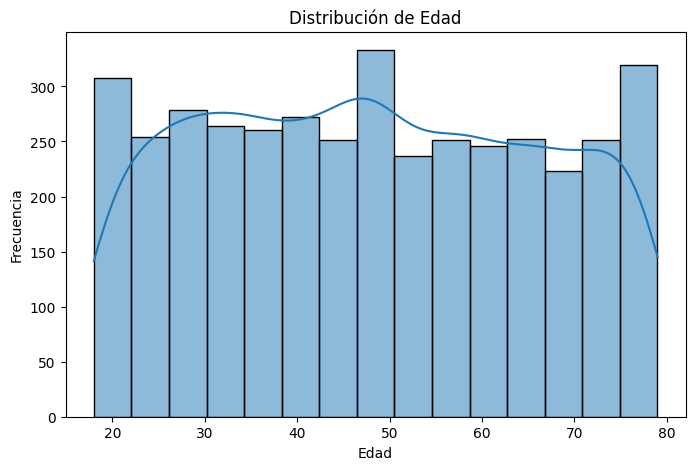

In [ ]:
# Histograma para visualizar la edad (age)
# Eliminar valores nulos si existen
edad = users['age'].dropna()

plt.figure(figsize=(8,5))
sns.histplot(edad, bins=15, kde=True)

plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()
plt.show()

💡Insights:
- Distribución sugiere que hay dos subpoblaciones distintas en los datos: Un grupo concentrado en la mediana edad (alrededor de 50 años) y otro grupo en edades más avanzadas (alrededor de 80 años).

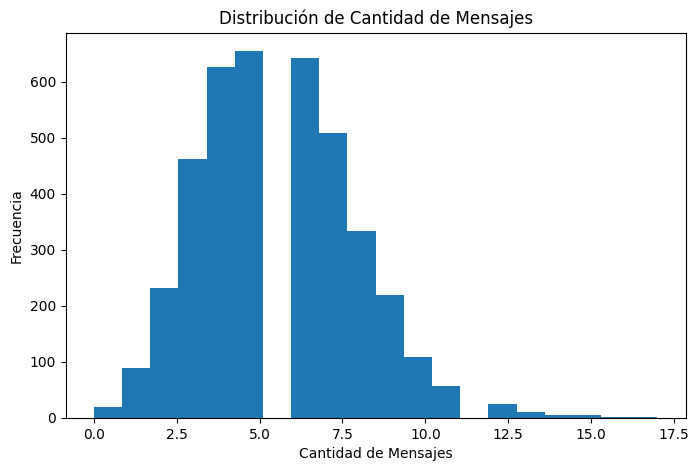

In [ ]:
# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(8,5))
plt.hist(users['cant_mensajes'].dropna(), bins=20)

plt.title('Distribución de Cantidad de Mensajes')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights:
- Distribución sesgada a la derecha. La mayor concentración de datos está en los valores bajos (3-7 mensajes). Hay una disminución gradual hacia la derecha. Existen algunos valores atípicos o poco frecuentes en el extremo superior (12-17 mensajes)

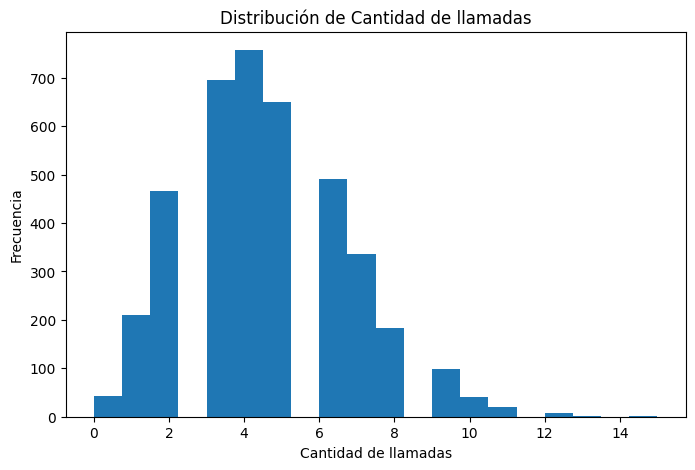

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))
plt.hist(users['cant_llamadas'].dropna(), bins=20)

plt.title('Distribución de Cantidad de llamadas')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights:
- Distribución muestra la cola que se extiende hacia la derecha (valores más altos), disminución gradual de frecuencia después del segundo pico y algunos valores poco frecuentes en el extremo superior (10-14 llamadas).

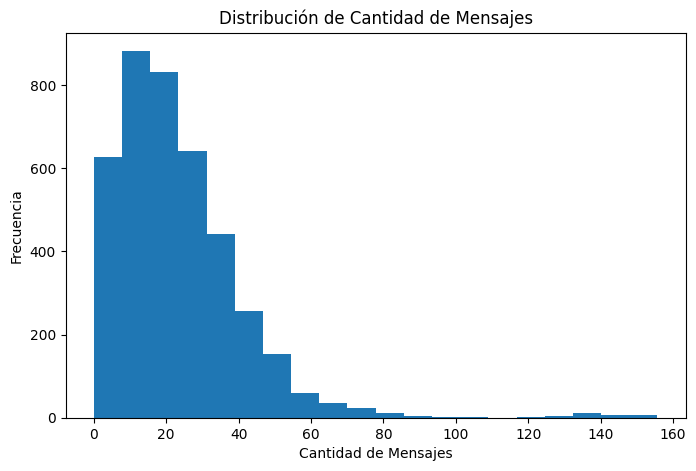

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))
plt.hist(users['cant_minutos_llamada'].dropna(), bins=20)

plt.title('Distribución de Cantidad de Mensajes')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights:
- Distribucion es una cola larga sesgada a la derecha. El pico máximo está en los valores más bajos (0-10 mensajes),disminución rápida y continua a medida que aumenta la cantidad de mensajes, y la frecuencia cae de manera exponencial, no gradual.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Generar boxplots automáticamente
for col in columnas_numericas:
    plt.figure(figsize=(12, 8))
    sns.boxplot(y=users[col], color='skyblue')
    plt.title(f"BoxPlot de {col}")
    plt.ylabel(col)
    plt.show()

💡Insights:
- Age: Presenta outlier -999 muy alejado del boxplot.
- cant_mensajes: Presenta outliers alejados del boxplot.
- cant_llamadas: Presenta muchos mas outliers pero mas cercanos del boxplot.
- cant_minutos_llamada: Presenta la mayor cantidad de outliers.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Recorrer cada columna
for col in columnas_limites:
    # Calcular Q1, Q3 e IQR
    Q1 = users[col].quantile(0.25)
    Q3 = users[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definir límites para outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtrar outliers
    outliers = users[(users[col] < limite_inferior) | (users[col] > limite_superior)][col]

    # Mostrar información
    print(f"\nColumna: {col}")
    print(f"Outliers encontrados ({len(outliers)}):")
    print(outliers.values)


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Mantener los outliers.Razón: No parecen errores, sino casos de uso real (usuarios más activos). Eliminarlos podría sesgar los análisis hacia usuarios promedio.
- cant_llamadas: mantener o no outliers, porqué? Mantener los outliers.Razón: No hay indicios de error de medición; son comportamientos extremos válidos.
- cant_minutos_llamada: mantener o no outliers, porqué?Aquí sí hay valores significativamente más altos que la mayoría, aunque aún podrían ser casos reales de usuarios con llamadas largas. Sin embargo, si los análisis van a calcular promedios o correlaciones, estos outliers podrían sesgar los resultados. Manternerlos depende del analisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

# Crear columna 'grupo_uso' basada en condiciones
def asignar_grupo(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicar función fila por fila
users['grupo_uso'] = users.apply(asignar_grupo, axis=1)


In [ ]:
# verificar cambios
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def asignar_grupo_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicar función fila por fila
users['grupo_edad'] = users.apply(asignar_grupo_edad, axis=1)

In [ ]:
# verificar cambios
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

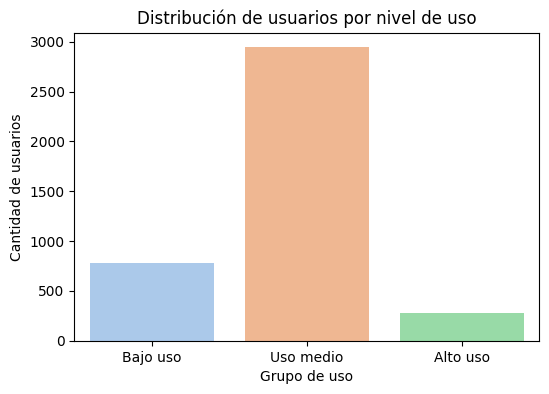

In [ ]:
# Visualización de los segmentos por uso

plt.figure(figsize=(6,4))
sns.countplot(data=users, x='grupo_uso', palette='pastel', order=['Bajo uso','Uso medio','Alto uso'])
plt.title('Distribución de usuarios por nivel de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


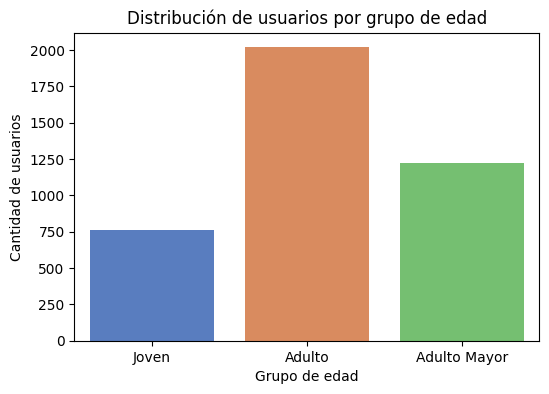

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=users, x='grupo_edad', palette='muted', order=['Joven','Adulto','Adulto Mayor'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Outliers.
- Valores nulos o faltantes.


🔍 **Segmentos por Edad**
- Se identificaron segmentos por edad: joven, adulto, y adulto mayor.
- El segmento de Adultos representan el segmento que mas hace uso de sus servicios móviles.


📊 **Segmentos por Nivel de Uso**
- Se identifican segmentos de nivel de uso: bajo, medio y alto.
- El nivel de uso medio respresenta la matoy cantidad de usuarios que representan esta tendencia.


➡️ Esto sugiere que los clientes adultos son los clientes que realmente usan los servicios móviles de ConnectaTel.


💡 **Recomendaciones**
- Enforcar las campanas de marketing hacia el segmento de clientes Adultos.
- Reducir fondos que van hacia las campanas de marketing dirigidos a los jovenes y mayores adultos para dirigirlos mayormente hacia las campanas de marketing del segmento adultos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`